# 3회차 · pandas & 시각화 — 데이터를 불러오고 눈으로 보기

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KimKangSoo123/Github_Colab_Integration_Practice/blob/main/week3/03_pandas_viz_KKS.ipynb)

**오늘의 목표 (약 3시간)**
- pandas DataFrame 개념
- 데이터 불러오기 · 훑어보기 (`head`, `info`, `describe`)
- 컬럼 선택 · 조건 필터링 · 결측치 확인
- matplotlib / seaborn 로 히스토그램 · 산점도 그리기
- 실습 데이터: **붓꽃(iris)**

**진행 방식**: 개념 → 예제 실행 → 🔧 빈칸 채우기 순서입니다.

*   Matplotlib & Seaborn 	: 파이썬에서 데이터를 그래프나 그림으로 그려주는 가장 대표적인 데이터 시각화 도구(라이브러리)

    Matplotlib 	: 세밀한 맞춤 설정이 가능한 기본 도구 => 그래프
    
    Seaborn 	: 예쁘고 복잡한 통계 그래프를 쉽게 만들 수 있게 도와주는 보조 도구 => 표


---
## 0. DataFrame이란?

pandas의 **DataFrame** 은 엑셀 표와 같습니다. 행은 샘플, 열은 특징(feature). NumPy 배열에 "열 이름"과 "인덱스"가 붙은 형태라고 보면 돼요.

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "name": ["A", "B", "C", "D"],
    "math": [85, 60, 92, 70],
    "eng":  [90, 55, 88, 72],
})
df

,name,math,eng
0,A,85,90
1,B,60,55
2,C,92,88
3,D,70,72


> 💡 Colab에서 DataFrame은 표로 예쁘게 렌더링됩니다. 마지막 줄에 `df` 만 쓰면 출력돼요.

---
## 1. 실제 데이터 불러오기 — 붓꽃(iris)

머신러닝 입문의 고전, 붓꽃 데이터입니다. 꽃잎/꽃받침 크기로 3가지 품종을 구분하는 데이터예요. seaborn에 내장돼 있어 바로 불러올 수 있습니다.

In [2]:
import seaborn as sns

iris = sns.load_dataset("iris")
iris.head()      # 앞 5줄 미리보기

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


*   아이리스(Iris) 데이터셋 	: 붓꽃의 4가지 측정값(sepal_length, sepal_width, petal_length, petal_width)과 품종(species) 정보로 이루어진 150개 행, 5개 열의 유명한 표본 데이터

In [3]:
print("모양(행, 열):", iris.shape)
print()
iris.info()      # 각 열의 타입과 결측치 여부

모양(행, 열): (150, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


*   Non-Null Count 	: 데이터 분석에서 비어 있지 않은(Null이 아닌) 값의 개수

In [4]:
iris.describe()  # 숫자 열의 통계 요약 (평균, 표준편차, 최소/최대 등)

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 🔧 과제 1-1
`iris` 데이터의 **뒤쪽 5줄**을 출력하세요. (힌트: `head` 의 반대)

=> iris.tail()

In [5]:
# TODO
iris.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


---
## 2. 컬럼 선택 · 필터링

특정 열만 보거나, 조건에 맞는 행만 골라냅니다. 2회차의 불리언 인덱싱과 같은 개념이에요.

In [6]:
# 열 하나 선택
print(iris["species"].value_counts())   # 품종별 개수

# 조건 필터링: 꽃잎 길이가 5보다 큰 행만
long_petal = iris[iris["petal_length"] > 5]
print()
print("꽃잎 긴 샘플 수:", len(long_petal))
long_petal.head()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

꽃잎 긴 샘플 수: 42


,sepal_length,sepal_width,petal_length,petal_width,species
83,6.0,2.7,5.1,1.6,versicolor
100,6.3,3.3,6.0,2.5,virginica
101,5.8,2.7,5.1,1.9,virginica
102,7.1,3.0,5.9,2.1,virginica
103,6.3,2.9,5.6,1.8,virginica


*   iris["species"] 	: 붓꽃(Iris) 데이터 등 표 형태로 정리된 데이터프레임 변수 안에서 꽃의 종류(품종)를 나타내는 열(column)을 고르는 것입니다.

*   .value_counts() 	: 해당 열에 있는 종류별 데이터가 각각 몇 개씩 있는지 개수를 세어 많은 순서대로 보여줍니다.

### 🔧 과제 2-1
품종이 `"setosa"` 인 행만 골라 `setosa` 에 저장하고, 그 개수를 출력하세요.

In [8]:
# TODO
setosa = iris[iris["species"] == "setosa"]
print("setosa 개수:", len(setosa))

setosa 개수: 50


### 🔧 과제 2-2 — 결측치 확인
실제 데이터엔 빈 값(결측치)이 흔합니다. 각 열의 결측치 개수를 세어보세요. (iris는 결측치가 없어 모두 0이 정상)

In [11]:
# TODO: isnull() 과 sum() 을 이어서 사용
missing = iris.isnull().sum()
print(missing)

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


*   isnull() : 값이 비어 있는지(NULL인지) 확인하거나 다른 값으로 바꾸는 함수

---
## 3. 시각화 — 데이터를 눈으로

숫자만 봐선 감이 안 옵니다. 그래프로 그리면 데이터의 분포와 관계가 한눈에 보여요.

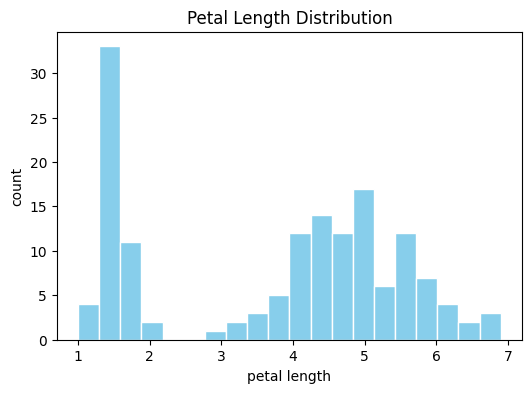

In [12]:
import matplotlib.pyplot as plt

# 히스토그램: 꽃잎 길이 분포
plt.figure(figsize=(6, 4))
plt.hist(iris["petal_length"], bins=20, color="skyblue", edgecolor="white")
plt.xlabel("petal length")
plt.ylabel("count")
plt.title("Petal Length Distribution")
plt.show()

*   plt.figure(figsize=(x, y)) : 파이썬의 시각화 라이브러리 맷플롯립(Matplotlib) 등에서 그래프(그림) 전체의 가로(x)와 세로(y) 크기를 지정하는 설정값

*   plt.hist(iris["petal_length"], bins=20, color="skyblue", edgecolor="white") : 붓꽃 꽃잎 길이의 분포를 20개의 하늘색 막대로 나누고 막대의 테두리 선은 하얀색인 히스토그램을 그린다.

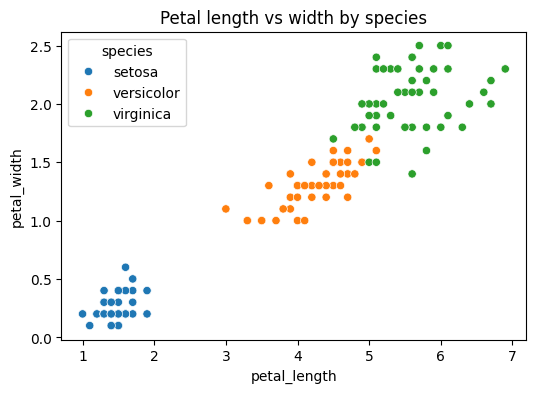

In [13]:
# 산점도: 두 특징의 관계를 품종별 색으로
plt.figure(figsize=(6, 4))
sns.scatterplot(data=iris, x="petal_length", y="petal_width", hue="species")
plt.title("Petal length vs width by species")
plt.show()

*   sns.scatterplot(data=iris, x="petal_length", y="petal_width", hue="species") : 붓꽃 데이터를 x축은 꽃잎 길이, y축은 꽃잎 너비로 나타내고 품종에 따라 그래프의 색상을 다르게 지정하는 산점도를 그린다.

> 💡 위 산점도를 보면 품종끼리 꽤 잘 나뉘죠? 이게 "이 데이터는 분류가 가능하겠다"는 직관을 줍니다. 4회차에서 이걸 실제 모델로 분류합니다.

### 🔧 오늘의 미니 과제 (제출용)
1. `sepal_length` (꽃받침 길이)의 **히스토그램**을 그리세요.
2. `sepal_length` vs `sepal_width` **산점도**를 품종별 색으로 그리고, 눈에 보이는 특징을 아래 마크다운 셀에 3줄로 정리하세요.

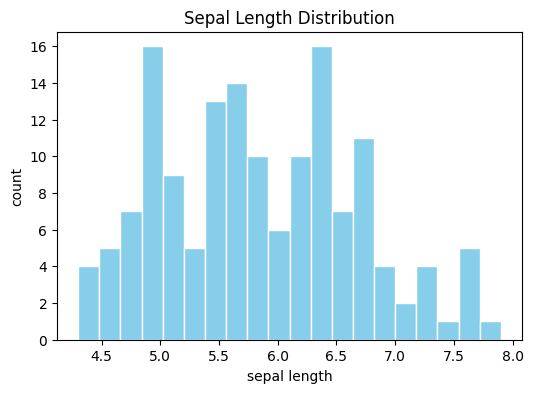

In [14]:
# 1) 히스토그램
plt.figure(figsize=(6, 4))
# TODO
plt.hist(iris["sepal_length"], bins=20, color="skyblue", edgecolor="white")
plt.xlabel("sepal length")
plt.ylabel("count")
plt.title("Sepal Length Distribution")
plt.show()

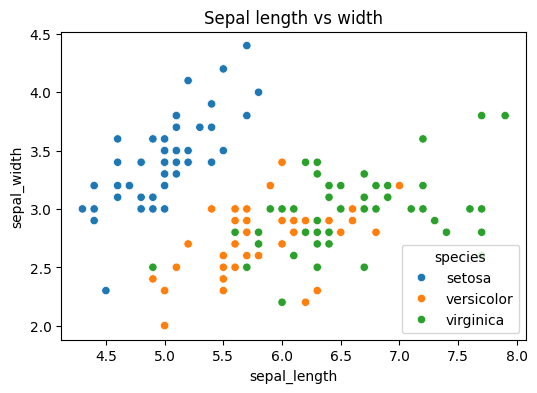

In [15]:
# 2) 산점도
plt.figure(figsize=(6, 4))
# TODO: sns.scatterplot 사용, x=sepal_length, y=sepal_width, hue=species
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species")
plt.title("Sepal length vs width")
plt.show()

**📝 여기에 발견한 점 3줄을 적으세요 (더블클릭해서 편집):**
1.
2.
3.

---
## 마무리 & 제출

**제출 방법**
1. `런타임 → 모두 실행` 으로 전체를 돌려 결과를 채웁니다.
2. `파일 → GitHub에 사본 저장` → 경로를 `members/본인이름/03_pandas_viz.ipynb` 로 지정합니다.
3. 커밋 메시지: `3회차 완료`

**복습 팁**: 막혔던 셀 아래에 마크다운 셀을 추가해 "왜 헷갈렸는지"를 한두 줄 적어두면 최고의 복습 노트가 됩니다.


**다음 회차 예고 (4회차)**: 드디어 머신러닝! 오늘 본 붓꽃 데이터로 첫 분류 모델을 학습시킵니다.